In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit
from pysr import PySRRegressor
from scipy.spatial import cKDTree

import os
from dotenv import load_dotenv
from pathlib import Path
load_dotenv()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


True

In [ ]:
NPi_ekstra_data = Path(os.getenv(rf"NPi_ekstra"))
df_new = pd.read_csv(NPi_ekstra_data)
df_new["redcap_repeat_instance"] = (
    df_new["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)
# relevant_columns = ["npi_left", "npi_right", "pupil_size_left", "pupil_size_right", "pupil_min_left", "pupil_min_right", "ch_left", "ch_right", "const_velocity_left", "const_velocity_right", "max_const_velocity_left", "max_const_velocity_right", "dilat_velocity_left", "dilat_velocity_right", "latency_left", "latency_right"]
# new_columns = [col for col in df_new.columns if col[:col.find("_t")].lower() in relevant_columns]
# df_new = df_new.dropna(subset=new_columns)
df_new = df_new[df_new["redcap_event_name"] == 'day_1_exam_t0__t4_arm_1']
df_new['record_id'].duplicated().sum()  # should be 0
columns_to_drop = ['redcap_event_name', 'redcap_repeat_instrument', 'redcap_repeat_instance'] + [col for col in df_new.columns if 'which_pupillometer' in col] + [col for col in df_new.columns if 'exploratory_pupillometry' in col] + [col for col in df_new.columns if "time_pupillometry" in col]
df_new.drop(columns=columns_to_drop, inplace=True)
long_df = pd.wide_to_long(
    df_new,
    stubnames=[
        'npi_right', 'npi_left',
        'pupil_size_right', 'pupil_size_left',
        'pupil_min_right', 'pupil_min_left',
        'ch_right', 'ch_left',
        'const_velocity_right', 'const_velocity_left',
        'latency_right', 'latency_left',
        'dilat_velocity_right', 'dilat_velocity_left',
        'max_const_velocity_right', 'max_const_velocity_left'
    ],
    i='record_id',
    j='redcap_repeat_instance',
    sep='_',
    suffix=r't\d+'
).reset_index()

long_df = pd.wide_to_long(
    long_df,
    stubnames=[
        'npi',
        'pupil_size',
        'pupil_min',
        'ch',
        'const_velocity',
        'latency',
        'dilat_velocity',
        'max_const_velocity'
    ],
    i=['record_id', 'redcap_repeat_instance'],
    j='eye',
    sep='_',
    suffix=r'(left|right)'
).reset_index()
long_df = long_df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])
long_df["record_id"] += 1000
long_df["eye"] = long_df["eye"].map({"left": 0, "right": 1})
long_df

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,latency,dilat_velocity,max_const_velocity
106,1054,t1,1,1.0,5.86,5.27,10.0,1.21,0.27,0.42,1.68
107,1054,t1,0,1.6,5.68,4.80,15.0,1.52,0.40,0.53,1.93
108,1055,t1,1,1.2,4.92,4.47,9.0,0.62,0.23,0.40,0.94
109,1055,t1,0,2.7,3.84,3.40,11.0,0.69,0.23,0.31,1.33
110,1056,t1,1,0.7,5.71,5.42,5.0,0.56,0.20,0.34,1.06
...,...,...,...,...,...,...,...,...,...,...,...
571,1070,t4,0,4.4,3.70,2.57,31.0,1.67,0.20,0.91,3.54
572,1071,t4,1,4.3,4.47,2.89,35.0,2.39,0.23,1.61,4.39
573,1071,t4,0,3.6,4.59,3.34,27.0,1.42,0.27,1.43,2.99
574,1072,t4,1,4.3,4.07,2.76,32.0,1.97,0.23,1.02,3.56


In [ ]:
#Dat
NPImeaures_noCHerro = Path(os.getenv(rf"NPI_noCHerror"))
df = pd.read_csv(NPImeaures_noCHerro)

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)
df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])

HC_left_data_path = Path(os.getenv(rf"HC_left_data_path"))
HC_right_data_path = Path(os.getenv(rf"HC_right_data_path"))
df_l = pd.read_csv(HC_left_data_path)
df_r = pd.read_csv(HC_right_data_path)
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

In [4]:
df = pd.concat([df, long_df], ignore_index=True)
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch"
])
df

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,...,LOR_early_gradient,LOR_late_gradient,50pct_PLR_time,50pct_LOR_time,50pct_early,50pct_late,SECONDS,FOUR,date_examination_merged,npi_left_merged
0,1,1,0.0,4.5,1.98,1.70,14.0,0.98,1.31,0.23,...,0.106599,0.014085,3.34,6.65,6.68,8.18,C,4.0,2024-12-09,4.5
1,1,2,0.0,4.5,2.08,1.79,14.0,0.89,1.44,0.27,...,0.060914,0.008048,3.27,6.48,6.81,9.22,C,4.0,2024-12-10,4.5
2,1,3,0.0,4.6,2.09,1.75,16.0,0.97,1.15,0.20,...,0.086294,0.006036,3.27,6.48,6.58,8.22,C,4.0,2024-12-11,4.6
3,1,4,0.0,4.6,2.16,1.82,16.0,1.07,1.41,0.17,...,0.071066,0.006036,4.58,6.01,6.58,8.02,C,4.0,2024-12-12,4.6
4,1,5,0.0,4.6,2.59,2.07,20.0,1.25,2.30,0.20,...,0.091371,0.008048,3.31,6.65,6.85,8.12,C,4.0,2024-12-13,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,1070,t4,0.0,4.4,3.70,2.57,31.0,1.67,3.54,0.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1102,1071,t4,1.0,4.3,4.47,2.89,35.0,2.39,4.39,0.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1103,1071,t4,0.0,3.6,4.59,3.34,27.0,1.42,2.99,0.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1104,1072,t4,1.0,4.3,4.07,2.76,32.0,1.97,3.56,0.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Outlier detection: ((Max - Min) / max) - ch > 0.01

In [5]:
df.iloc[np.where(abs((df["pupil_size"] - df["pupil_min"]) / df["pupil_size"] - df["ch"] / 100) > 0.01)]

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,...,LOR_early_gradient,LOR_late_gradient,50pct_PLR_time,50pct_LOR_time,50pct_early,50pct_late,SECONDS,FOUR,date_examination_merged,npi_left_merged
150,34,6,0.0,4.1,2.62,2.77,6.0,1.95,2.78,0.2,...,0.451777,0.138833,3.71,10.49,6.75,10.69,C,5.0,2025-01-22,4.1


In [6]:
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy controls

df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df["z_const_velocity"] = z_score(df["const_velocity"], df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
df["z_max_const_velocity"] = z_score(df["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df["z_dilat_velocity"] = z_score(df["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df["z_latency"] = z_score(df["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())
df.to_csv("done.csv")
df

KeyError: 'pupil_size'

In [56]:
df = pd.read_csv("done.csv")
df = df.drop(columns="Unnamed: 0")
df.describe()

,record_id,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,dilat_velocity,z_pupil_size,z_pupil_min,z_ch,z_const_velocity,z_max_const_velocity,z_dilat_velocity,z_latency
count,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.00000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000,2074.000000
mean,187.432498,0.502893,4.031533,3.093777,2.428862,19.515429,1.338158,2.067420,0.24771,0.561205,-1.682018,-0.879761,-2.756401,-1.990070,-2.206253,-1.584137,0.214576
std,255.329309,0.500112,0.803981,1.238794,0.895870,10.685704,0.873438,1.331432,0.04884,0.407464,1.186452,1.178566,1.769591,1.430099,1.485089,1.515319,1.292259
min,1.000000,0.000000,0.500000,1.230000,1.030000,1.000000,0.020000,0.110000,0.13000,0.000000,-3.467046,-2.720040,-5.822623,-4.148321,-4.389574,-3.671208,-2.899909
25%,60.000000,0.000000,3.700000,2.120000,1.820000,11.000000,0.660000,1.010000,0.23000,0.230000,-2.614650,-1.680752,-4.166587,-3.100434,-3.385707,-2.815859,-0.254007
50%,121.000000,1.000000,4.300000,2.720000,2.210000,19.000000,1.170000,1.725000,0.23000,0.455000,-2.040002,-1.167686,-2.841758,-2.265400,-2.588191,-1.979105,-0.254007
75%,203.750000,1.000000,4.600000,3.840000,2.810000,28.000000,1.880000,2.950000,0.27000,0.850000,-0.967325,-0.378353,-1.351325,-1.102901,-1.221817,-0.510137,0.804354
max,1072.000000,1.000000,4.900000,7.580000,7.030000,51.000000,6.100000,7.130000,0.60000,1.910000,2.614650,5.173286,2.457558,5.806601,3.440585,3.431904,9.535833


In [ ]:
match_features = df[["z_pupil_size", "z_pupil_min"]].values
tree = cKDTree(match_features)
tolerance = 0.1
pairs = tree.query_pairs(r=tolerance)

compares = ["ch", "const_velocity", "max_const_velocity", "dilat_velocity", "latency"]
z_threshold = 1  # fælles tærskel i SD-enheder

results = []
for i, j in pairs:
    row_i, row_j = df.iloc[i], df.iloc[j]

    entry_base = {
        "record_id_i": row_i["record_id"],
        "record_id_j": row_j["record_id"],
        "npi_diff": row_i["npi"] - row_j["npi"],
        "size_diff": row_i["pupil_size"] - row_j["pupil_size"],
        "min_diff": row_i["pupil_min"] - row_j["pupil_min"],
    }

    for feat in compares:
        z_col = f"z_{feat}"
        z_diff = row_i[z_col] - row_j[z_col]

        if abs(z_diff) > z_threshold:
            entry = dict(entry_base)
            entry["feature"] = feat
            entry[f"{feat}_diff"] = row_i[feat] - row_j[feat]
            entry[f"z_{feat}_diff"] = z_diff
            results.append(entry)

matched_df = pd.DataFrame(results)
matched_df.describe()

,record_id_i,record_id_j,npi_diff,size_diff,min_diff,const_velocity_diff,z_const_velocity_diff,latency_diff,z_latency_diff,dilat_velocity_diff,z_dilat_velocity_diff,max_const_velocity_diff,z_max_const_velocity_diff,ch_diff,z_ch_diff
count,19197.000000,19197.000000,19197.000000,19197.000000,19197.000000,2713.000000,2713.000000,12889.000000,12889.000000,2680.000000,2680.000000,805.000000,805.000000,110.000000,110.000000
mean,103.695161,178.127207,-0.002297,-0.000254,0.000265,0.022142,0.036253,-0.000263,-0.006959,-0.054455,-0.202514,-0.094112,-0.104973,-1.036364,-0.171626
std,88.155195,189.872735,0.204080,0.052575,0.038293,0.906521,1.484267,0.086503,2.288798,0.427576,1.590114,1.246102,1.389911,7.033246,1.164731
min,1.000000,1.000000,-0.900000,-0.100000,-0.070000,-3.380000,-5.534151,-0.340000,-8.996069,-1.370000,-5.094903,-2.370000,-2.643515,-8.000000,-1.324829
25%,42.000000,85.000000,-0.100000,-0.040000,-0.030000,-0.770000,-1.260738,-0.070000,-1.852132,-0.370000,-1.375996,-1.130000,-1.260410,-7.000000,-1.159225
50%,93.000000,155.000000,0.000000,0.000000,0.000000,0.620000,1.015140,-0.040000,-1.058361,-0.280000,-1.041294,-0.920000,-1.026175,-7.000000,-1.159225
75%,154.000000,214.000000,0.100000,0.040000,0.030000,0.780000,1.277112,0.070000,1.852132,0.340000,1.264428,1.060000,1.182332,7.000000,1.159225
max,1072.000000,1072.000000,0.800000,0.100000,0.070000,3.070000,5.026581,0.400000,10.583610,1.530000,5.689928,3.060000,3.413146,8.000000,1.324829


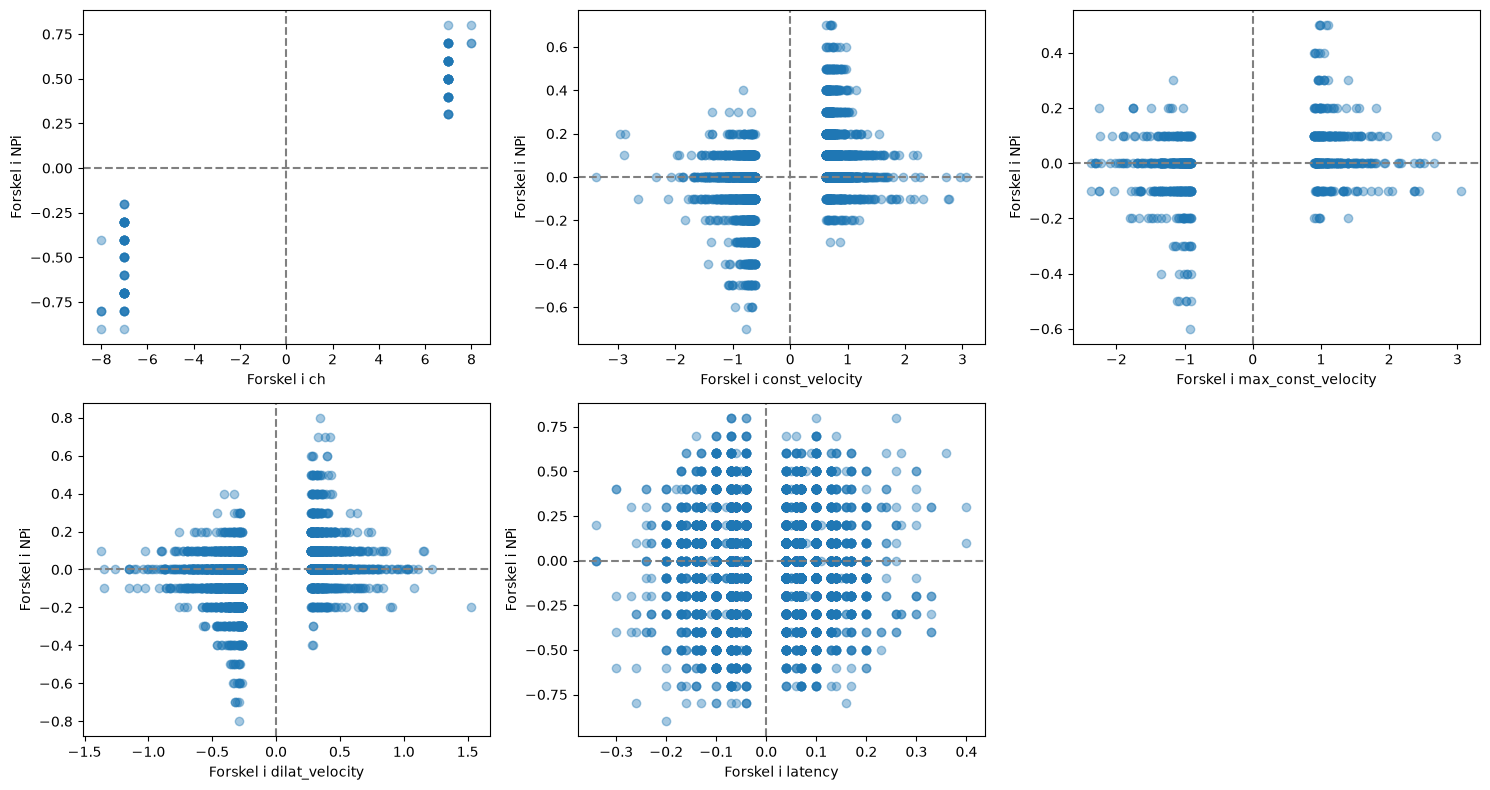

In [9]:
import numpy as np

n = len(compares)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, compares):
    col = f"{feat}_diff"
    ax.scatter(matched_df[col], matched_df["npi_diff"], alpha=0.4)
    ax.set_xlabel(f"Forskel i {feat}")
    ax.set_ylabel("Forskel i NPi")
    ax.axhline(0, color="gray", linestyle="--")
    ax.axvline(0, color="gray", linestyle="--")

# Fjern eventuelle tomme subplots hvis compares ikke går op i ncols
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig("outputs/all_diffs_vs_npi_diff.pdf", dpi=1200)

In [10]:
def logit_transform(y, y_min=0.0, y_max=5.0, eps=1e-6):
    """
    Logit-transform a bounded target.
    """
    y_scaled = (y - y_min) / (y_max - y_min)
    y_scaled = np.clip(y_scaled, eps, 1 - eps)
    return np.log(y_scaled / (1 - y_scaled))


def inverse_logit_transform(z, y_min=0.0, y_max=5.0):
    """
    Inverse logit-transform back to original scale.
    """
    y_scaled = 1 / (1 + np.exp(-z))
    return y_min + (y_max - y_min) * y_scaled

In [11]:
# from pysr import PySRRegressor
# import sympy

# y = df["npi"]
# y = logit_transform(y)
# X = df[[
# "pupil_size",
# "pupil_min",
# "ch"
# ]]
# X

# model = PySRRegressor(
#     niterations=200,
#     binary_operators=["+", "-", "*", "/"],
#     unary_operators=["exp", "square", "logistic(x) = 1 / (1 + exp(-x))"],  
#     extra_sympy_mappings={"logistic": lambda x: 1 / (1 + sympy.exp(-x))},
#     maxsize=20,                      # cap expression complexity
#     model_selection="best",          # picks best accuracy/complexity tradeoff point
#     loss="loss(x, y) = (x - y)^2",   # fit on logit-scale z, not raw NPi
#     complexity_of_operators={"exp": 3, "logistic": 3},  # penalize nonlinear ops more
# )

# model.fit(X, y)
# print(model.equations_)   # Pareto front: complexity vs loss

# from pysr import PySRRegressor
# import sympy

# model = PySRRegressor(
#     niterations=1000,
#     populations=30,
#     maxsize=10,

#     binary_operators=[
#         "+",
#         "-",
#         "*",
#         "/",
#     ],

#     unary_operators=[
#         "sqrt",
#         "abs",
#         "tanh",
#         "square",
#         "log",
#         "exp",]
#    )
# model.fit(X, y)

In [12]:
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
   "z_ch",
    "z_const_velocity",
    "z_max_const_velocity",
    "z_latency",
    "z_dilat_velocity"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values

y = (y_raw - 0) / (5 - 0)

eps = 1e-6
y = np.clip(y, eps, 1 - eps)

z = np.log(y / (1 - y))

X_trans = X.copy()

In [13]:
#Gam fit
gam = LinearGAM(
    s(0, n_splines=20) + # pupil size 
    s(1,constraints='monotonic_dec',  n_splines=10) +  # pupil min
    s(2, constraints='monotonic_inc', n_splines=10) +  # CH
    l(3) +  
    l(4) +  
    l(5)+l(6))

from sklearn.neighbors import KernelDensity

kde = KernelDensity(bandwidth=0.3).fit(z.reshape(-1,1))
log_dens = kde.score_samples(z.reshape(-1,1))
density_weights = 1 / np.exp(log_dens)
density_weights /= density_weights.mean()
cap = np.percentile(density_weights, 95)
density_weights_capped = np.clip(density_weights, None, cap)
density_weights_capped /= density_weights_capped.mean()

gam.gridsearch(X_trans, z, weights=density_weights_capped)

# gam.gridsearch(X_trans, z)


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + l(3) + l(4) + l(5) + l(6) + intercept, 
   tol=0.0001, verbose=False)

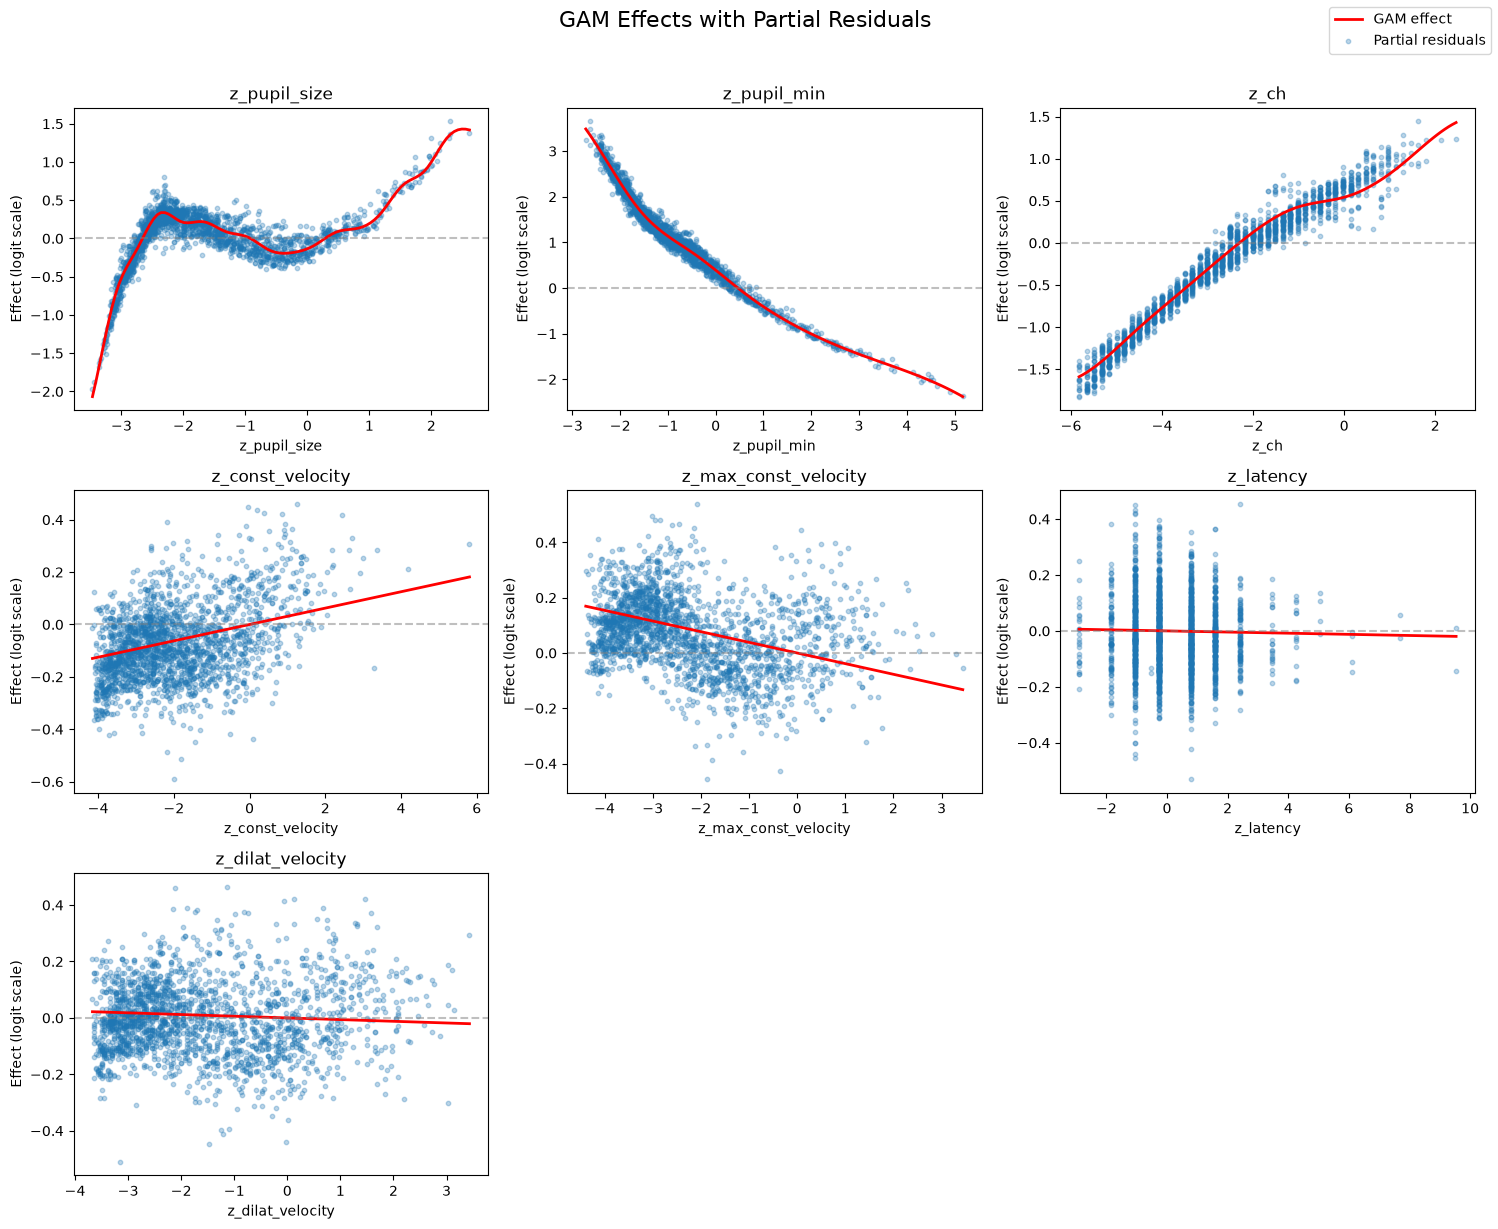

In [14]:
#   Plot gam functions
n_features = len(FEATURES)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharey=False 
)

axes = axes.flatten()

y_pred = gam.predict(X_trans)

for i in range(n_features):
    ax = axes[i]

    XX = gam.generate_X_grid(term=i)
    pdp = gam.partial_dependence(term=i, X=XX)

    ax.plot(
        XX[:, gam.terms[i].feature],
        pdp,
        color="red",
        linewidth=2,
        label="GAM effect"
    )

    x_vals = X_trans.iloc[:, i].values

    residual = z - y_pred + gam.partial_dependence(term=i, X=X)

    ax.scatter(
        x_vals,
        residual,
        alpha=0.3,
        s=10,
        label="Partial residuals"
    )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(FEATURES[i])
    ax.set_xlabel(FEATURES[i])
    ax.set_ylabel("Effect (logit scale)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("GAM Effects with Partial Residuals", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("GAM_after.pdf", bbox_inches='tight', dpi=1200)


In [15]:
y_pred = 1 / (1 + np.exp(-y_pred))
npi_pred = y_pred * (5 - 0) + 0

In [16]:
print(r2_score(y_raw, np.round(npi_pred, 1) ))
print(mean_squared_error(y_raw, np.round(npi_pred, 1) ))
print(mean_absolute_error(y_raw, np.round(npi_pred, 1) ))

0.9891339855452196
0.0070202507232401175
0.05380906460945035


In [17]:
coef = gam.coef_
intercept = gam._modelmat(np.zeros((1, X_trans.shape[1]))) @ gam.coef_

In [18]:
for i in range(0, 8):
    print(i)
    print(f"beta_{i} =", gam.coef_[gam.terms.get_coef_indices(i)])

0
beta_0 = [-2.9686989  -2.22245227 -0.5465481  -0.20823848  0.51031977  0.12904095
  0.28388615  0.0481395   0.06545204 -0.20054938 -0.19847071 -0.11995839
  0.13103732  0.103314    0.26926183  0.7848829   0.7845395   1.41780725
  1.46178562  1.24762073]
1
beta_1 = [ 4.70144901  3.69328177  1.42887212  0.83515678 -0.21542126 -0.92812655
 -1.43600768 -1.82552628 -2.32177981 -3.15972675]
2
beta_2 = [-1.69687491 -1.69687491 -1.05225793 -0.52962472  0.0283864   0.48883845
  0.48883845  0.89780136  1.53588222  1.53588222]
3
beta_3 = [0.0312562]
4
beta_4 = [-0.03855666]
5
beta_5 = [-0.00204845]
6
beta_6 = [-0.00598288]
7
beta_7 = [0.77217124]


In [19]:
# ---------- AIC/BIC helper ----------
def aic_bic(y_true, y_pred, n_params):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    aic = n * np.log(rss / n) + 2 * n_params
    bic = n * np.log(rss / n) + n_params * np.log(n)
    return aic, bic

# Min

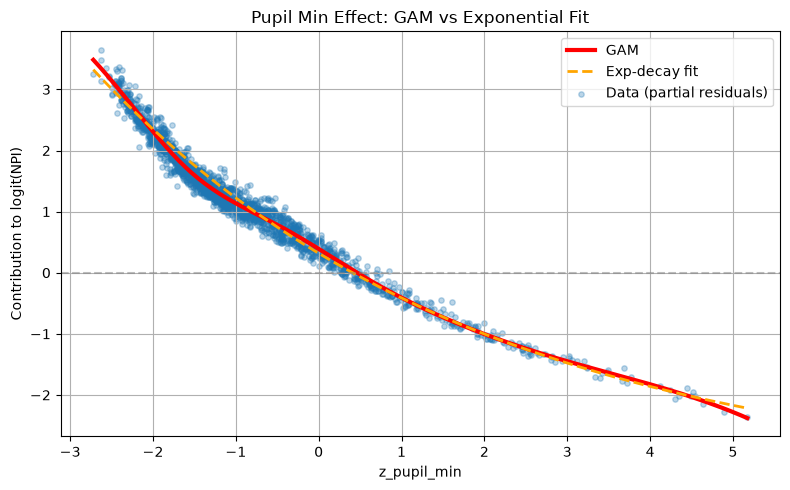

In [20]:

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


# X interval
x_vals = np.linspace(
    X_trans["z_pupil_min"].min(),
    X_trans["z_pupil_min"].max(),
    200
)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_pupil_min"] = x_vals

# GAM partial dependence 
y_gam = gam.partial_dependence(term=1, X=X_fake)

# fitted curve 
params_min, _ = curve_fit(exp_decay, x_vals, y_gam, maxfev=10000)
y_fit = exp_decay(x_vals, *params_min)



# ADD DATAPOINTS


# Predictions
y_pred = gam.predict(X_trans)

# Partial residuals
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=1, X=X_trans)
)

# Raw x-values
x_data = X_trans["z_pupil_min"].values

aic_sig, bic_sig = aic_bic(
    partial_res, exp_decay(x_data, *params_min), n_params=3
)

# PLOT

plt.figure(figsize=(8,5))

# GAM curve
plt.plot(x_vals, y_gam, color="red",label="GAM", linewidth=3)

# Parametric fit
plt.plot(x_vals, y_fit, '--',color="orange", label="Exp-decay fit", linewidth=2)

plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_min")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Min Effect: GAM vs Exponential Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
from pysr import PySRRegressor

# --- PySR fit directly on the raw residuals (not y_gam) ---
# Restrict operators to ones that tend to produce monotonic behavior;
# still include sin/cos so we don't rule out a real non-monotonic shape by assumption,
# but we'll explicitly check monotonicity afterward either way.
model_pysr_min = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "square", "cube"],
    model_selection="best",
    maxsize=10,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial",
)

model_pysr_min.fit(x_vals.reshape(-1, 1), y_gam)
print(model_pysr_min)

c:\Users\NTres\OneDrive\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.260e+05
Progress: 1283 / 31000 total iterations (4.139%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.476e+00  0.000e+00  y = -0.1926
3           4.224e-01  8.843e-01  y = x₀ * -0.5566
5           1.132e-01  6.583e-01  y = (x₀ * -0.67128) + 0.63081
7           8.386e-02  1.502e-01  y = x₀ * ((x₀ * 0.1015) + -0.87462)
8           4.857e-03  2.849e+00  y = (exp(x₀ * -0.21428) + -0.91741) / 0.26408
10          2.873e-03  2.625e-01  y = ((x₀ * -0.33218) + -0.70876) + exp(x₀ * -0.43436)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressio

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                        -0.19260108   
	1        0.884254                                    x0 * -0.5565951   
	2        0.658286                     (x0 * -0.6712834) + 0.63080925   
	3        0.951307        (143.29855 / (x0 + 13.600814)) + -10.097653   
	4        1.256232  (exp(x0 * -0.21540199) + -0.91572905) / 0.2650715   
	5  >>>>  0.411806  (x0 / ((x0 * -0.14495312) + -1.269521)) + 0.30...   
	6        0.103410  (exp(x0 * -0.43440494) + -0.70879525) + (x0 * ...   
	
	       loss  complexity  
	0  2.476399           1  
	1  0.422443           3  
	2  0.113237           5  
	3  0.016892           7  
	4  0.004810           8  
	5  0.003186           9  
	6  0.002873          10  
]
  - outputs\20260718_084625_gtz1tR\hall_of_fame.csv


In [22]:
model_pysr_min.get_best().sympy_format.simplify()

(0.3841282364733 - 0.956140476323824*x0)/(0.14495312*x0 + 1.269521)

In [23]:
# Replace this with whatever functional form PySR actually returns
def min_pysr_expr(x, a, b, c, d, e):
    return a + b / (c + d * np.exp(-x) + e / x)

def min_pysr_expr(x, a, b, c):
    return (a + b * x) / (x + c)


Model                             AIC         BIC
Sigmoid+threshold            -7431.64    -7414.73
PySR                         -7979.69    -7962.78


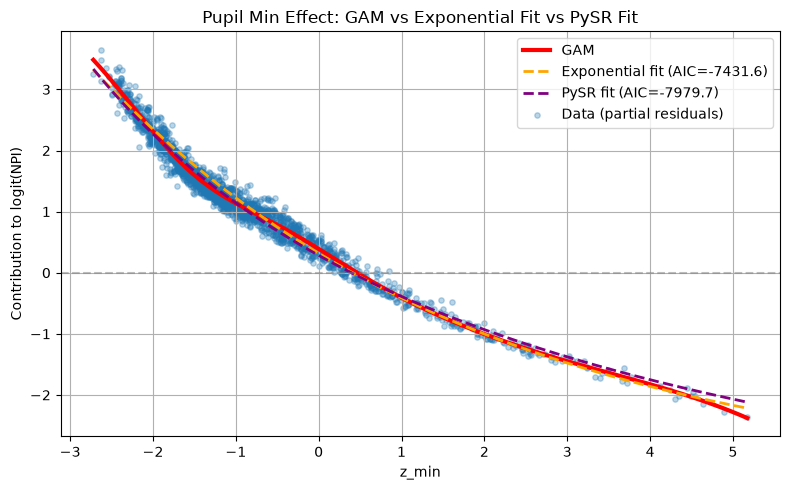

In [24]:
# params_pysr_min, _ = curve_fit(min_pysr_expr, x_data, partial_res, p0=[0.31, -2.75, 0.35, 0.0084, 3.616], maxfev=20000)
params_pysr_min, _ = curve_fit(min_pysr_expr, x_data, partial_res, p0=[2.692, -6.641, 8.818], maxfev=20000)

y_fit_pysr = min_pysr_expr(x_vals, *params_pysr_min)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, min_pysr_expr(x_data, *params_pysr_min), n_params=len(params_pysr_min)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x_vals, y_gam, label="GAM",color="red", linewidth=3)
# exponential fit
plt.plot(x_vals, y_fit, '--',color="orange", label=f"Exponential fit (AIC={aic_sig:.1f})", linewidth=2)
# PySR fit
plt.plot(x_vals, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_min")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Min Effect: GAM vs Exponential Fit vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Min_comparison.pdf", bbox_inches='tight', dpi=1200)
plt.show()

# CH

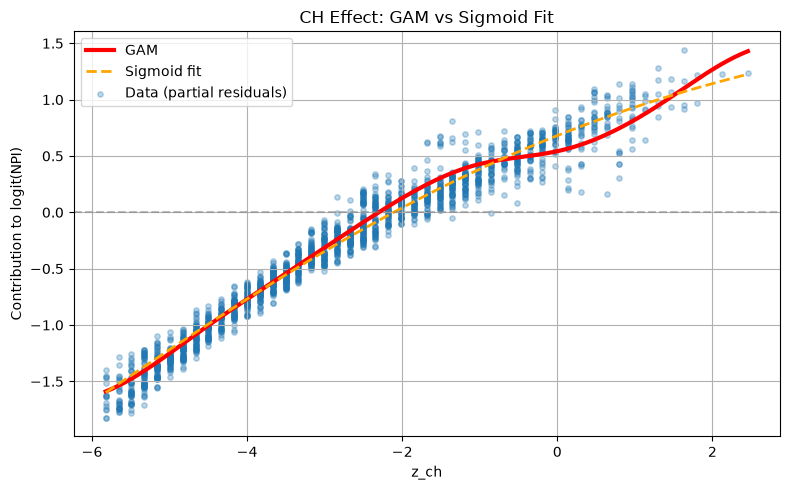

In [25]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b

x_vals = np.linspace(
    X_trans["z_ch"].min(),
    X_trans["z_ch"].max(),
    200
)
X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_ch"] = x_vals

# GAM partial dependence
y_gam = gam.partial_dependence(term=2, X=X_fake)

# Fit sigmoid
p0 = [
    y_gam.max() - y_gam.min(),
    1.0,
    np.median(x_vals),
    np.mean(y_gam)
]
bounds = (
    [0,   0.01, x_vals.min(), -10],
    [10, 10,    x_vals.max(), 10]
)
p0 = np.clip(p0, bounds[0], bounds[1])
params_ch, _ = curve_fit(
    sigmoid_shifted,
    x_vals,
    y_gam,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
y_fit = sigmoid_shifted(x_vals, *params_ch)

# ADD DATAPOINTS
y_pred = gam.predict(X_trans)
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=2, X=X_trans)
)
x_data = X_trans["z_ch"].values


aic_sig, bic_sig = aic_bic(
    partial_res, sigmoid_shifted(x_data, *params_ch), n_params=4
)

# Plot
plt.figure(figsize=(8,5))
# GAM curve
plt.plot(x_vals, y_gam, color="red", label="GAM", linewidth=3)
# sigmoid fit
plt.plot(x_vals, y_fit, '--', color="orange", label="Sigmoid fit", linewidth=2)
# data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_ch")
plt.ylabel("Contribution to logit(NPI)")
plt.title("CH Effect: GAM vs Sigmoid Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
from pysr import PySRRegressor

# --- PySR fit directly on the raw residuals (not y_gam) ---
# Restrict operators to ones that tend to produce monotonic behavior;
# still include sin/cos so we don't rule out a real non-monotonic shape by assumption,
# but we'll explicitly check monotonicity afterward either way.
model_ch = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "square", "cube", "sqrt", "log"],
    model_selection="best",
    maxsize=10,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial"
)

model_ch.fit(x_vals.reshape(-1, 1), y_gam)
print(model_ch)

c:\Users\NTres\OneDrive\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.320e+05
Progress: 1354 / 31000 total iterations (4.368%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.064e-01  0.000e+00  y = 0.033918
3           2.708e-01  4.793e-01  y = x₀ * 0.22532
5           1.659e-02  1.396e+00  y = (x₀ + 1.7805) * 0.34573
6           1.269e-02  2.680e-01  y = 1.6679 - exp(x₀ * -0.21479)
8           6.762e-03  3.148e-01  y = 1.704 - square((x₀ * -0.13836) + 1.0161)
9           6.762e-03  3.886e-05  y = (x₀ + 2.0919) * (0.32127 - (x₀ * 0.019213))
10          4.361e-03  4.385e-01  y = (x₀ * (0.27178 - (square(x₀) * -0.0039169))) + 0.62392
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.064e-01  0.000e+00  y = 0.033918
3           2.708e-01  4.793e-01  y = x₀ * 0.22532
5           1.659e-02  1.396e+00  y = (x₀ + 1.7805) * 0.34573
6           1.269e-02  2.680e-01  y = 1.6681 - exp(x₀ * -0.2148)
7           5.755e-03  7.910e-01  y = log(cube(1.2445 - (x₀ * -0.11563)))
10          1.287e-03  4.992e-01  y = (x₀ + (1.7381 / (exp(x₀) + 0.64335))) * 0.54515
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs\20260718_084844_tR77ba\hall_of_fame.csv
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                         0.03391847   
	1        0.479336                                    x0 * 0.22532195   
	2        1.396236                      (x0 + 1.7805477) * 0.34573436   

In [27]:
model_ch.get_best().sympy_format.simplify()

(0.5451541*x0*(exp(x0) + 0.6433469) + 0.94751854881127)/(exp(x0) + 0.6433469)

In [28]:
# Replace this with whatever functional form PySR actually returns
def ch_pysr_expr(x, a, b, c, d):
    return a * x + b * np.sin(c * x) + d

def ch_pysr_expr(x, a, b):
    return np.log((a*x + b)**3)


Model                             AIC         BIC
Sigmoid+threshold            -8621.36    -8598.81
PySR                         -8765.47    -8754.19


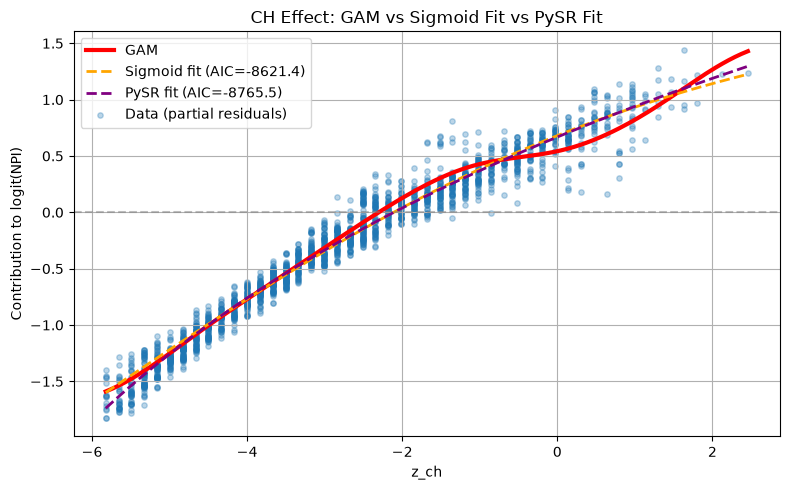

In [29]:
params_pysr_ch, _ = curve_fit(ch_pysr_expr, x_data, partial_res, p0=[0.115, 1.244], maxfev=20000)

y_fit_pysr = ch_pysr_expr(x_vals, *params_pysr_ch)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, ch_pysr_expr(x_data, *params_pysr_ch), n_params=len(params_pysr_ch)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x_vals, y_gam, label="GAM",color="red", linewidth=3)
# sigmoid fit
plt.plot(x_vals, y_fit, '--',color="orange", label=f"Sigmoid fit (AIC={aic_sig:.1f})", linewidth=2)
# PySR fit
plt.plot(x_vals, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_ch")
plt.ylabel("Contribution to logit(NPI)")
plt.title("CH Effect: GAM vs Sigmoid Fit vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("CH_comparison.pdf", bbox_inches='tight', dpi=1200)
plt.show()

# Size

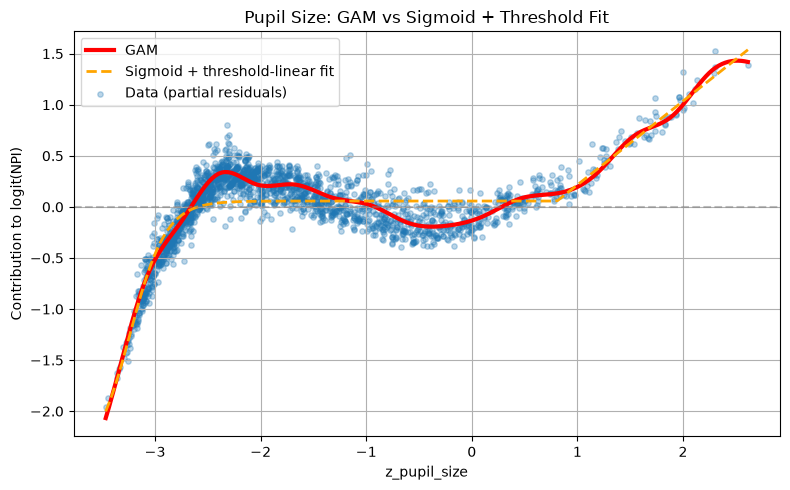

In [ ]:


# Same as before using max size
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# Model function
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

x = np.linspace(
    X_trans["z_pupil_size"].min(),
    X_trans["z_pupil_size"].max(),
    200
)
X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x), 1)),
    columns=X_trans.columns
)
X_fake["z_pupil_size"] = x
y_gam = gam.partial_dependence(term=0, X=X_fake)

p0 = [
    y_gam.max() - y_gam.min(),  # A
    1.0,                        # k
    np.median(x),               # x0
    0.2,                        # m
    y_gam.min(),             # b
    0.0      
]
bounds=(
                [0, 0.01, x.min(), -5, -10, x.min()],
                [10,10, x.max(),  5,  10,  x.max()]
            )
p0 = np.clip(p0, bounds[0], bounds[1])
params_size, _ = curve_fit(
    sigmoid_plus_threshold_linear,
    x,
    y_gam,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
y_fit = sigmoid_plus_threshold_linear(x, *params_size)
y_pred = gam.predict(X_trans)
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=0, X=X_trans)
)
x_data = X_trans["z_pupil_size"].values

# Refit sigmoid+threshold on the RAW data (fair comparison basis)
params_size_raw, _ = curve_fit(
    sigmoid_plus_threshold_linear, x_data, partial_res,
    p0=p0, bounds=bounds, maxfev=20000
)
aic_sig, bic_sig = aic_bic(
    partial_res, sigmoid_plus_threshold_linear(x_data, *params_size_raw), n_params=6
)

plt.figure(figsize=(8, 5))

# GAM
plt.plot(x, y_gam, label="GAM",color="red", linewidth=3)

# fit
plt.plot(x, y_fit, '--',color="orange", label="Sigmoid + threshold-linear fit", linewidth=2)

# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_size")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Size: GAM vs Sigmoid + Threshold Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# ---------- PySR fit (deterministic, on raw partial residuals) ----------
model_pysr = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "square", "cube", "sqrt", "log"],
    model_selection="best",
    maxsize=15,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial"
)
model_pysr.fit(x.reshape(-1, 1), y_gam)
print(model_pysr)

c:\Users\NTres\OneDrive\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.410e+05
Progress: 1403 / 31000 total iterations (4.526%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.860e-01  0.000e+00  y = 0.1602
3           2.374e-01  2.430e-01  y = x₀ * 0.22995
4           1.733e-01  3.146e-01  y = exp(x₀) * 0.12304
5           1.669e-01  3.801e-02  y = (x₀ + 1.0301) * 0.26529
6           6.629e-02  9.231e-01  y = cube(x₀ + 0.6693) * 0.051146
8           5.401e-02  1.024e-01  y = ((x₀ * 0.062924) + 0.12042) * square(x₀)
10          4.624e-02  7.772e-02  y = cube(0.23024 - (x₀ * -0.42895)) + (x₀ * -0.18022)
12          1.492e-02  5.654e-01  y = ((4.7242 - x₀) * square(x₀)) * ((x₀ * 0.020512) + 0.05...
                                      2479)
13          1.492e-02  1.788e-07  y = ((((x₀ * -0.020511) + 0.044423) * x₀

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.860e-01  0.000e+00  y = 0.1602
3           2.374e-01  2.430e-01  y = x₀ * 0.22995
4           1.733e-01  3.146e-01  y = exp(x₀) * 0.12304
5           1.545e-01  1.147e-01  y = log(log(x₀ + 4.6308))
6           6.629e-02  8.464e-01  y = cube(x₀ + 0.6693) * 0.05115
7           4.646e-02  3.555e-01  y = cube(log((x₀ + 4.0799) * 0.42837))
8           4.018e-02  1.453e-01  y = cube(log(square((x₀ + 6.2102) * -0.20033)))
9           2.050e-02  6.728e-01  y = square(x₀) * ((cube(x₀) * 0.0076366) + 0.1457)
11          1.379e-02  1.984e-01  y = (cube((x₀ * 0.13127) + -0.28277) + 0.24218) * square(x...
                                      ₀)
12          1.029e-02  2.931e-01  y = (square(x₀) - square(-0.8595 - (cube(x₀) * -0.090741))...
                                      ) * 0.24178
13          9.239e-03  1.073e-01  y = (square(x₀) * (cub

In [32]:
model_pysr.get_best().sympy_format.simplify()

0.21723157*(x0 + 0.19644791)**2 - 0.21723157*(0.09248973*x0**3 - 0.6923604)**2

In [33]:
def pysr_expr(x, a, b, c, d):
    return x**2 * (a + b * (x + c)**2) + d

def pysr_expr(x, a, b):
    return a * x**2 * np.log(x + b)

def pysr_expr(x, a, b, c):
    return a * x**2 + b * x * np.exp(-x) + c


Model                             AIC         BIC
Sigmoid+threshold            -6896.81    -6862.99
PySR                         -8224.18    -8207.27


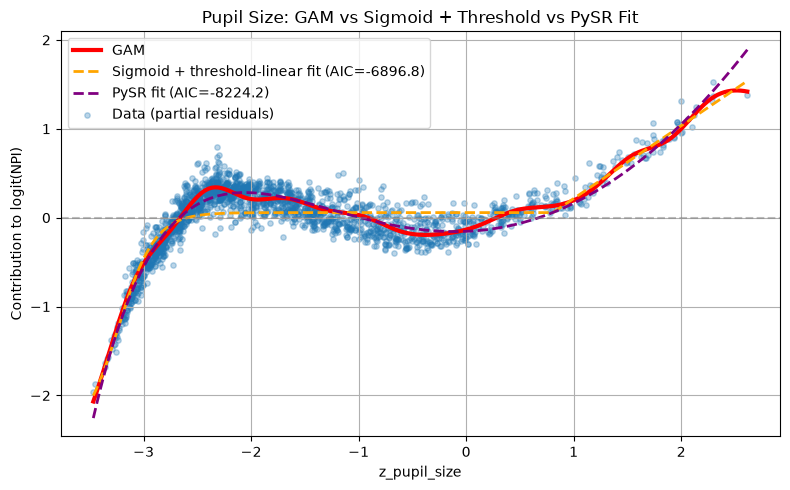

In [50]:
params_pysr_size, _ = curve_fit(pysr_expr, x_data, partial_res, p0=[0.2648, 0.04682, -0.0916], maxfev=20000)

y_fit_pysr = pysr_expr(x, *params_pysr_size)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, pysr_expr(x_data, *params_pysr_size), n_params=len(params_pysr_size)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x, y_gam, label="GAM",color="red", linewidth=3)
# sigmoid fit
plt.plot(x, y_fit, '--',color="orange", label=f"Sigmoid + threshold-linear fit (AIC={aic_sig:.1f})", linewidth=2)
# PySR fit
plt.plot(x, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_pupil_size")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Size: GAM vs Sigmoid + Threshold vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Size_comparison.pdf", bbox_inches='tight', dpi=1200)
plt.show()

In [35]:
def f_min(x):
    return params_min[0] * np.exp(-params_min[1] * x) + params_min[2]
    # return params_pysr_min[0] + params_pysr_min[1] / (params_pysr_min[2] + params_pysr_min[3] * np.exp(-x) + params_pysr_min[4] / x)

def f_ch(x):
    return np.log((params_pysr_ch[0] * x + params_pysr_ch[1])**3)
    # return params_pysr_ch[0] * x + params_pysr_ch[1] * np.sin(params_pysr_ch[2] * x) + params_pysr_ch[3]

def f_size(x):
    return params_pysr_size[0] * x**2 + params_pysr_size[1] * x * np.exp(-x) + params_pysr_size[1]
    # return params_pysr_size[0] * x**2 * np.log(x + params_pysr_size[1])
    # return x**2 * (params_pysr_size[0] + params_pysr_size[1] * (x + params_pysr_size[2])**2) + params_pysr_size[3]
    # return x * (params_pysr_size[0] * x + params_pysr_size[1]) + params_pysr_size[2] * (x**3 + params_pysr_size[3])**2
    # return x * np.log(np.log(params_pysr_size[0] * x + params_pysr_size[1])**2 + params_pysr_size[2]) + params_pysr_size[3]

    # return (params_pysr_size[0] * x**3 + params_pysr_size[1]*x + params_pysr_size[2]) * np.sin(x + params_pysr_size[3])

# def pysr_expr(x):
#     return x * (params_pysr_size[0] * x + params_pysr_size[1]) + params_pysr_size[2] * (x**3 + params_pysr_size[3])**2

# def f_size(x):
#     return params_size[0] * sigmoid(params_size[1]  * (x - params_size[2] )) + params_size[3]  * np.maximum(0, x - params_size[5] ) + params_size[4] 



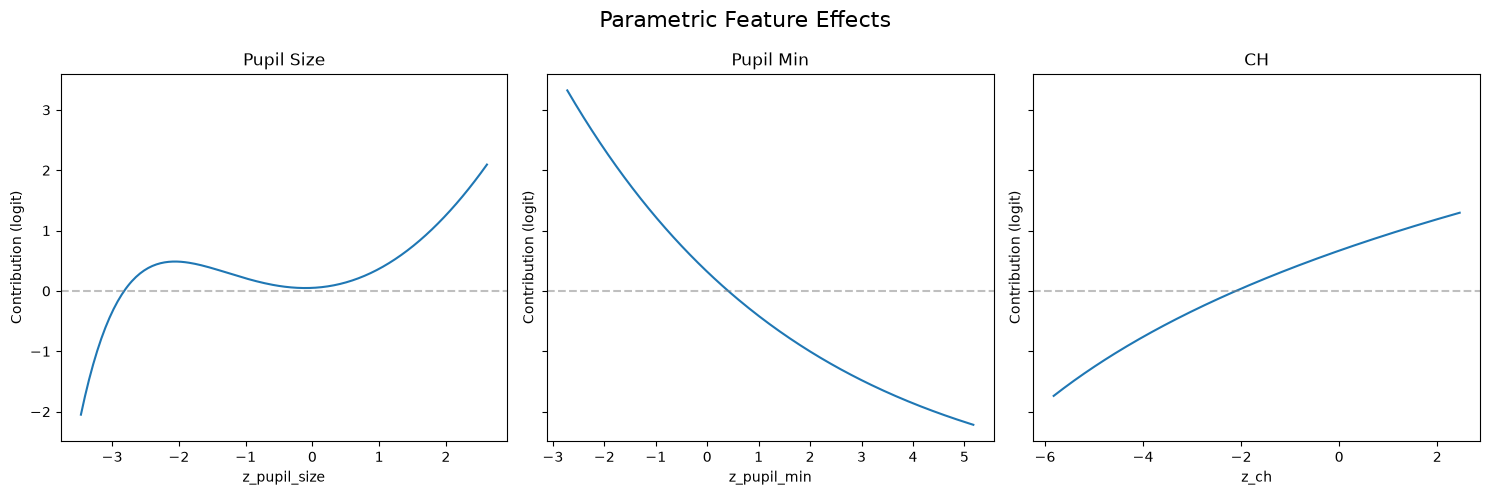

In [36]:
# Create grids based on feature ranges
x_size = np.linspace(X_trans["z_pupil_size"].min(), X_trans["z_pupil_size"].max(), 200)
x_min  = np.linspace(X_trans["z_pupil_min"].min(),  X_trans["z_pupil_min"].max(), 200)
x_ch   = np.linspace(X_trans["z_ch"].min(),         X_trans["z_ch"].max(), 200)

# functions
y_size = f_size(x_size)
y_min  = f_min(x_min)
y_ch   = f_ch(x_ch)


# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].plot(x_size, y_size)
axes[0].set_title("Pupil Size")
axes[0].set_xlabel("z_pupil_size")

axes[1].plot(x_min, y_min)
axes[1].set_title("Pupil Min")
axes[1].set_xlabel("z_pupil_min")

axes[2].plot(x_ch, y_ch)
axes[2].set_title("CH")
axes[2].set_xlabel("z_ch")

for ax in axes:
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Contribution (logit)")

plt.suptitle("Parametric Feature Effects", fontsize=16)
plt.tight_layout()
plt.show()

In [37]:
def predict_z(df):
    return (
        intercept
        + f_size(df["z_pupil_size"].values)
        + f_min(df["z_pupil_min"].values)
        + f_ch(df["z_ch"].values)
        + gam.coef_[gam.terms.get_coef_indices(3)]* df["z_const_velocity"].values
        + gam.coef_[gam.terms.get_coef_indices(4)] * df["z_max_const_velocity"].values
        + gam.coef_[gam.terms.get_coef_indices(5)] * df["z_latency"].values
        + gam.coef_[gam.terms.get_coef_indices(6)] * df["z_dilat_velocity"].values
    )

In [38]:
z_pred = predict_z(df)
y_pred_scaled = inverse_logit_transform(z_pred)

# rescale to original NPi range
npi_pred =np.round(y_pred_scaled,1)

In [39]:
y_true = df["npi"].values

mae = mean_absolute_error(y_true, npi_pred)
rmse = np.sqrt(mean_squared_error(y_true, npi_pred))
r2 = r2_score(y_true, npi_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5034715525554484
RMSE: 0.5829959533148451
R²: 0.47392370127309247


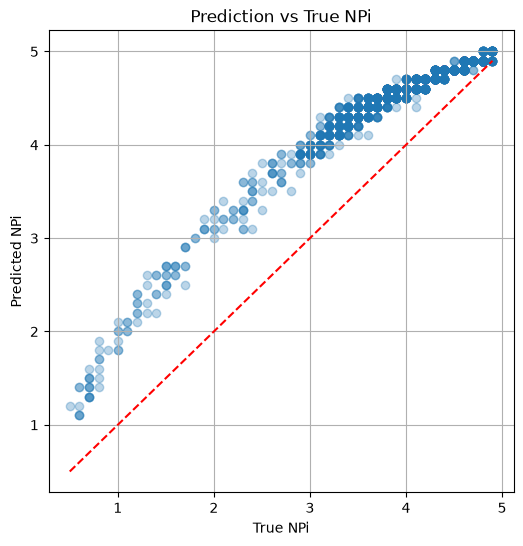

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, npi_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True NPi")
plt.grid()
plt.show()

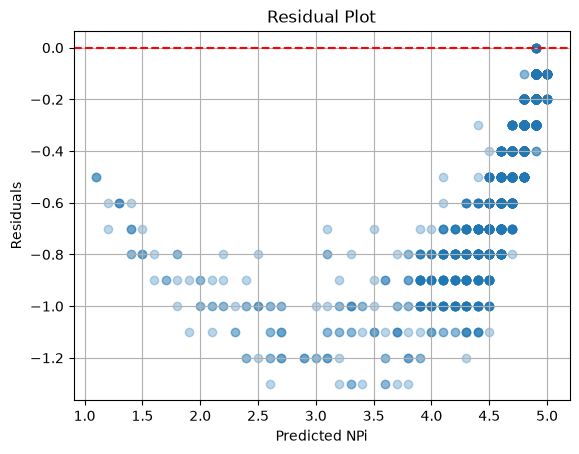

In [41]:
residuals = y_true - npi_pred

plt.scatter(npi_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted NPi")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [42]:
from sklearn.linear_model import LinearRegression

# predicted z
z_pred = predict_z(df)

# transform true NPi to logit space
y = df["npi"].values / 5
y = np.clip(y, 1e-6, 1 - 1e-6)
z_true = np.log(y / (1 - y))

# fit linear correction
reg = LinearRegression().fit(z_pred.reshape(-1,1), z_true)

a = reg.coef_[0]
b = reg.intercept_

print("Correction: z_corrected = %.4f * z_pred + %.4f" % (a, b))

Correction: z_corrected = 0.9628 * z_pred + -0.9339


In [43]:
z_corrected = a * z_pred + b

npi_pred = np.round(1/(1+np.exp(-z_corrected)) * 5,1)



mae = mean_absolute_error(y_true, npi_pred)
rmse = np.sqrt(mean_squared_error(y_true, npi_pred))
r2 = r2_score(y_true, npi_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.06268081002892961
RMSE: 0.09746052287859205
R²: 0.9852980436291776


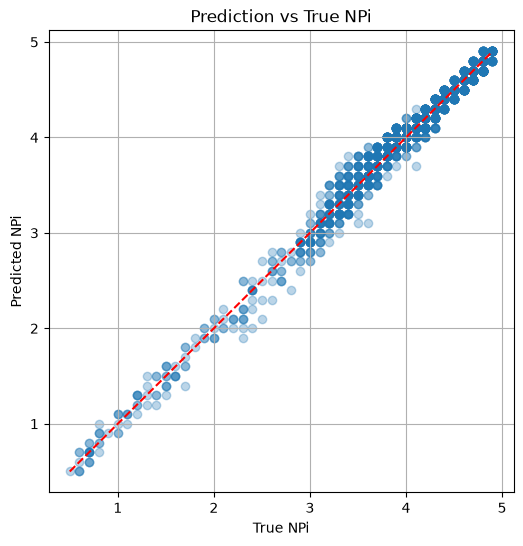

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, npi_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True NPi")
plt.grid()
plt.show()

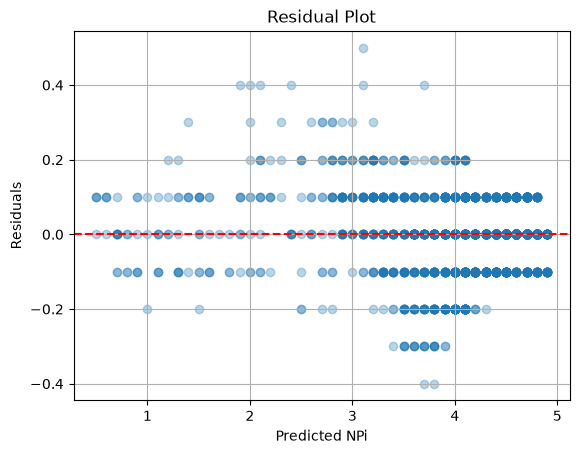

In [45]:
residuals = y_true - npi_pred

plt.scatter(npi_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted NPi")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

Check the outliers

In [46]:
# Find high-error patients
df_results = df.copy()
df_results["npi_pred"] = npi_pred
df_results["error"] = np.abs(df_results["npi_pred"] - df_results["npi"])


# Show top 10 highest errors
top_errors = (
    df_results
    .nlargest(10, "error")
    [["record_id", "redcap_repeat_instance", "eye", "npi", "npi_pred", "error"]]
    .reset_index(drop=True)
)

#print(top_errors) # Commented out for privacy reasons

From this we can go and check, and we found that the 3 largest errors have massive mistakes in how their CH is written. 
Seems like human error (miss typed)